In [1]:
import pandas as pd
import os
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Paths
csv_path = '/content/drive/MyDrive/MRI_PET_10_FEB_ADNI2_2_10_2026.csv'
mri_dir = '/content/drive/MyDrive/ADNI_MRI_Only'
pet_dir = '/content/drive/MyDrive/ADNI_PET_Only'

# Load the original Metadata
df = pd.read_csv(csv_path)

# 3. Helper function to find what 2D images we successfully processed
def get_processed_ids(base_dir):
    ids = []
    for group in ['AD', 'CN']:
        folder = os.path.join(base_dir, group)
        if os.path.exists(folder):
            for f in os.listdir(folder):
                if f.endswith('.png'):
                    ids.append(f.replace('.png', ''))
    return ids

mri_ids = get_processed_ids(mri_dir)
pet_ids = get_processed_ids(pet_dir)

# 4. Filter CSV for the exact images we have on Drive
mri_df = df[df['Image Data ID'].isin(mri_ids)][['Subject', 'Group', 'Image Data ID']]
pet_df = df[df['Image Data ID'].isin(pet_ids)][['Subject', 'Group', 'Image Data ID']]

# We only need one MRI and one PET per patient for this baseline
mri_df = mri_df.drop_duplicates(subset=['Subject'])
pet_df = pet_df.drop_duplicates(subset=['Subject'])

# 5. THE MERGE: Match MRI and PET by the Subject's ID
paired_df = pd.merge(mri_df, pet_df, on=['Subject', 'Group'], suffixes=('_MRI', '_PET'))

# Add the exact file paths so the model can load the images later
paired_df['MRI_Path'] = paired_df.apply(lambda x: f"{mri_dir}/{x['Group']}/{x['Image Data ID_MRI']}.png", axis=1)
paired_df['PET_Path'] = paired_df.apply(lambda x: f"{pet_dir}/{x['Group']}/{x['Image Data ID_PET']}.png", axis=1)

# Shuffle the data
paired_df = paired_df.sample(frac=1, random_state=42).reset_index(drop=True)

# 6. Save this manifest for your research paper!
manifest_save_path = '/content/drive/MyDrive/ADNI_Multimodal_Manifest.csv'
paired_df.to_csv(manifest_save_path, index=False)

print(f"Matchmaker Success! We found {len(paired_df)} valid Multimodal pairs.")
print(f"Manifest saved to: {manifest_save_path}")
print("\nClass distribution:")
print(paired_df['Group'].value_counts())

Mounted at /content/drive
Matchmaker Success! We found 100 valid Multimodal pairs.
Manifest saved to: /content/drive/MyDrive/ADNI_Multimodal_Manifest.csv

Class distribution:
Group
AD    50
CN    50
Name: count, dtype: int64


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, concatenate
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Dual-Input Data Pipeline
# ---------------------------------------------------------
# Convert 'AD'/'CN' to 1 and 0
paired_df['Label'] = paired_df['Group'].apply(lambda x: 1 if x == 'AD' else 0)

# Split into Training (80%) and Validation/Testing (20%)
train_df, val_df = train_test_split(paired_df, test_size=0.2, stratify=paired_df['Label'], random_state=42)

print(f"Training on {len(train_df)} Multimodal pairs. Testing on {len(val_df)} pairs.")

# The loader function: Loads both images, normalizes them, and returns a dictionary
def load_and_preprocess_pair(mri_path, pet_path, label):
    # MRI Processing
    mri_img = tf.io.read_file(mri_path)
    mri_img = tf.image.decode_png(mri_img, channels=3)
    mri_img = tf.image.resize(mri_img, [224, 224])
    mri_img = mri_img / 255.0

    # PET Processing
    pet_img = tf.io.read_file(pet_path)
    pet_img = tf.image.decode_png(pet_img, channels=3)
    pet_img = tf.image.resize(pet_img, [224, 224])
    pet_img = pet_img / 255.0

    # Format required by Keras Functional API for multiple inputs
    return ({"mri_input": mri_img, "pet_input": pet_img}, label)

BATCH_SIZE = 16

# Build tf.data datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_df['MRI_Path'].values, train_df['PET_Path'].values, train_df['Label'].values))
train_dataset = train_dataset.map(load_and_preprocess_pair, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=100).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_df['MRI_Path'].values, val_df['PET_Path'].values, val_df['Label'].values))
val_dataset = val_dataset.map(load_and_preprocess_pair, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ---------------------------------------------------------
# 2. Build the Y-Shaped Fusion CNN Architecture
# ---------------------------------------------------------

# --- BRANCH A: MRI ---
mri_input = Input(shape=(224, 224, 3), name="mri_input")
x = Conv2D(32, (3,3), activation='relu')(mri_input)
x = MaxPooling2D(2,2)(x)
x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D(2,2)(x)
x = Conv2D(128, (3,3), activation='relu')(x)
x = MaxPooling2D(2,2)(x)
mri_features = Flatten()(x)
mri_features = Dense(64, activation='relu')(mri_features)

# --- BRANCH B: PET ---
pet_input = Input(shape=(224, 224, 3), name="pet_input")
y = Conv2D(32, (3,3), activation='relu')(pet_input)
y = MaxPooling2D(2,2)(y)
y = Conv2D(64, (3,3), activation='relu')(y)
y = MaxPooling2D(2,2)(y)
y = Conv2D(128, (3,3), activation='relu')(y)
y = MaxPooling2D(2,2)(y)
pet_features = Flatten()(y)
pet_features = Dense(64, activation='relu')(pet_features)

# --- FUSION LAYER ---
# This merges the 64 structural features with the 64 metabolic features!
merged = concatenate([mri_features, pet_features])

# Let the network "think" about the combined features
z = Dense(128, activation='relu')(merged)
z = Dropout(0.5)(z)

# Final Binary Decision
output = Dense(1, activation='sigmoid', name="output")(z)

# ---------------------------------------------------------
# 3. Compile and Train
# ---------------------------------------------------------
fusion_model = Model(inputs=[mri_input, pet_input], outputs=output)

fusion_model.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

print("\nStarting Multimodal Fusion Training...\n")

EPOCHS = 15
history_fusion = fusion_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset
)

print("\nMultimodal Training Complete!")

Training on 80 Multimodal pairs. Testing on 20 pairs.

Starting Multimodal Fusion Training...

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.4089 - loss: 0.7573 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.6069 - loss: 0.6797 - val_accuracy: 0.5000 - val_loss: 0.6961
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.4125 - loss: 0.7092 - val_accuracy: 0.4000 - val_loss: 0.6978
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.5852 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6989
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.7021 - loss: 0.6731 - val_accuracy: 0.5000 - val_loss: 0.7071
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.4616 - loss: 0.7133 - val_accuracy: 0.3000 - val_loss: 0.7116
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.5271 - loss: 0.6673 - val_accuracy: 0.3500 - val_loss: 0.7242
Epoch 8/15
5/5 ━━━━━━━━━━━━━━

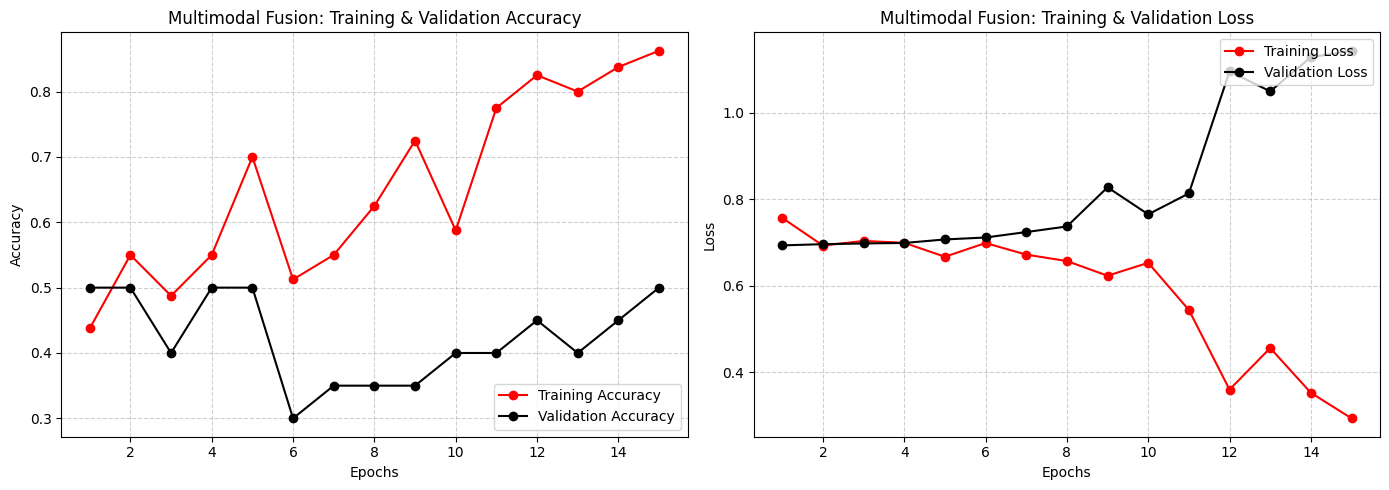

Generating predictions for Multimodal Confusion Matrix...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 465ms/step


<module 'seaborn' from '/usr/local/lib/python3.12/dist-packages/seaborn/__init__.py'>

<Figure size 600x500 with 0 Axes>

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------------------------------------------
# 1. Plot Training vs. Validation Graphs (Fusion Model)
# ---------------------------------------------------------
acc = history_fusion.history['accuracy']
val_acc = history_fusion.history['val_accuracy']
loss = history_fusion.history['loss']
val_loss = history_fusion.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', color='red')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', color='black')
plt.title('Multimodal Fusion: Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o', color='red')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o', color='black')
plt.title('Multimodal Fusion: Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Get Predictions for Confusion Matrix
# ---------------------------------------------------------
print("Generating predictions for Multimodal Confusion Matrix...")

# We use the validation dataset to get the model's predictions
predictions_fusion = fusion_model.predict(val_dataset)
predicted_classes_fusion = (predictions_fusion > 0.5).astype("int32").flatten()

# Get the true labels from our validation dataframe
true_classes_fusion = val_df['Label'].values
class_labels = ['CN (0)', 'AD (1)']

# ---------------------------------------------------------
# 3. Plot Confusion Matrix
# ---------------------------------------------------------
cm_fusion = confusion_matrix(true_classes_fusion, predicted_classes_fusion)

plt.figure(figsize=(6, 5))
sns